In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast

# Loading Data 
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) # Convert string representation of list to actual list

# Filter for Data Analyst
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [2]:
# Extracting the month from the job_posted_date column
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Exploding the job_skills column to have one skill per row
df_DA_explode = df_DA.explode('job_skills')

# Creating a pivot table to count the number of job postings for each skill by month
df_DA_pivot =df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

#  Create a total count row that sums all the skill counts at the bottom of the dataframe
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

# Sort skills by count
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total') # drop Total row


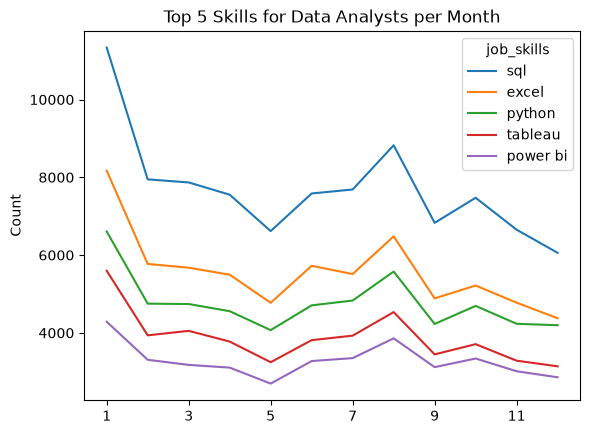

In [3]:
# Plot top 5 skills for data analyst by month
df_DA_pivot.iloc[:,:5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

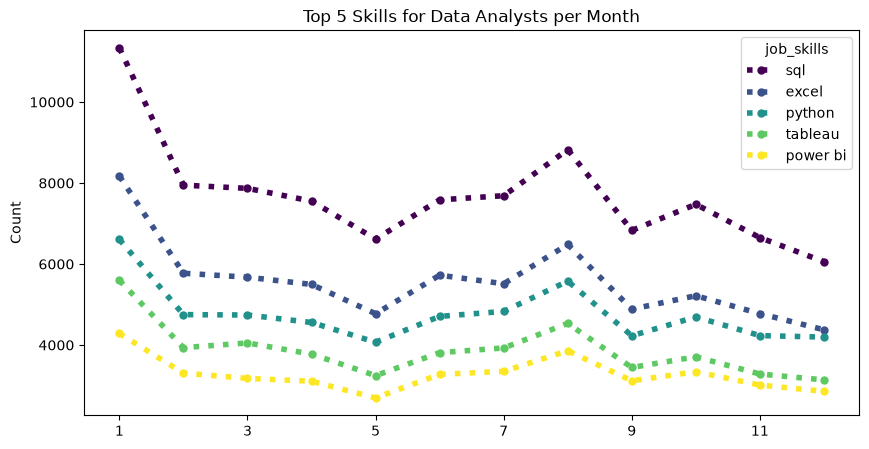

In [ ]:
# Customizing line chart
df_DA_pivot.iloc[:,:5].plot(
    kind ='line',
    linewidth=4,
    linestyle=':', #options: '-', '--', '_.'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    markersize=5,
    marker='o', #options: 'o', 'x', '+', '*', 's', 
    figsize=(10, 5)
)
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()